# Resultados cerrados y peticiones de Francisco

**Cómo leerlo.** El notebook tiene dos partes que no se mezclan. La **parte I**
son resultados terminados: cada uno tiene artefacto con procedencia y test de
regresión en el repo. La **parte II** es material de trabajo para las peticiones
de la sesión del 6 de agosto: aquí se prueban cosas y algunas no funcionan.

**Procedencia.** Cada número se regenera en su celda o se lee de un CSV
versionado. Nada escrito a mano.

**Los tres regímenes, con sus nombres completos.** A lo largo del notebook se
distinguen siempre: **estático** (las pruebas se fijan de antemano), **dinámico
binario** (adaptativo, la prueba responde si hay o no al menos un sano) y
**dinámico aumentado** (adaptativo, la prueba devuelve el conteo de sanos).

Convención: `q` es la probabilidad de estar **sano**. El régimen de interés es
`q < 0.5`, o sea prevalencia alta.

In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))
import math, itertools, csv
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, GRIS, AMBAR, TINTA = '#2563eb', '#6b7280', '#d97706', '#374151'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'grid.linewidth': 0.5, 'font.size': 10})

RAIZ = Path(os.path.dirname(os.path.dirname(os.path.abspath(''))))
RES = RAIZ / 'results'
print('repo:', RAIZ.name)

repo: group-count-dynamic


---
# PARTE I — Resultados cerrados

Todo lo de esta parte tiene artefacto con procedencia y test de regresión. Los
números no van a cambiar salvo que cambie el modelo.

## 1. La escalera exacta

Diez personas, cada una sana con probabilidad 0.2, y tres pruebas. Tres pruebas
individuales certifican 3 × 0.2 = 0.6 personas en promedio. Ésa es la referencia
contra la que se mide todo lo demás.

Hay dos perillas independientes: que la prueba **cuente** en vez de responder
sí/no, y que las pruebas **se adapten** a lo observado. Se prenden por separado.

**Afirmación.** Contar sin adaptarse vale casi lo mismo que adaptarse sin
contar, y las dos juntas valen más que la suma de sus partes.

In [2]:
from augmented.experiments_separacion_n10 import (
    dynamic_value, laminar_value, static_value)
from augmented.provenance import read_stamp

esc = pd.read_csv(RES / 'separacion_n10_q02.csv')
print(esc[['B', 'static_binary', 'dynamic_binary', 'static_augmented',
           'dynamic_augmented_laminar', 'dynamic_augmented']].to_string(index=False))
print('\nprocedencia:', read_stamp(RES / 'separacion_n10_q02.csv')['generator'])

# Autoverificacion: el CSV se reproduce recomputando desde cero en B=2.
N, Q = 10, 0.2
fila2 = esc[esc.B == 2].iloc[0]
assert abs(static_value(N, 2, False, Q) - fila2.static_binary) < 1e-9
assert abs(static_value(N, 2, True, Q) - fila2.static_augmented) < 1e-9
assert abs(dynamic_value(N, 2, False, Q) - fila2.dynamic_binary) < 1e-9
assert abs(dynamic_value(N, 2, True, Q) - fila2.dynamic_augmented) < 1e-9
assert abs(laminar_value(N, 2, Q) - fila2.dynamic_augmented_laminar) < 1e-9
print('\nOK: el CSV se reproduce recomputando B=2 desde cero')

 B  static_binary  dynamic_binary  static_augmented  dynamic_augmented_laminar  dynamic_augmented
 1            0.2        0.200000             0.200                   0.200000            0.20000
 2            0.4        0.488000             0.408                   0.536000            0.53600
 3            0.6        0.790285             0.800                   0.928243            1.00032
 4            NaN             NaN               NaN                   1.288971                NaN
 5            NaN             NaN               NaN                   1.544054                NaN
 6            NaN             NaN               NaN                   1.791137                NaN
 7            NaN             NaN               NaN                   1.913624                NaN
 8            NaN             NaN               NaN                   1.978111                NaN

procedencia: augmented.experiments_separacion_n10.main

OK: el CSV se reproduce recomputando B=2 desde cero


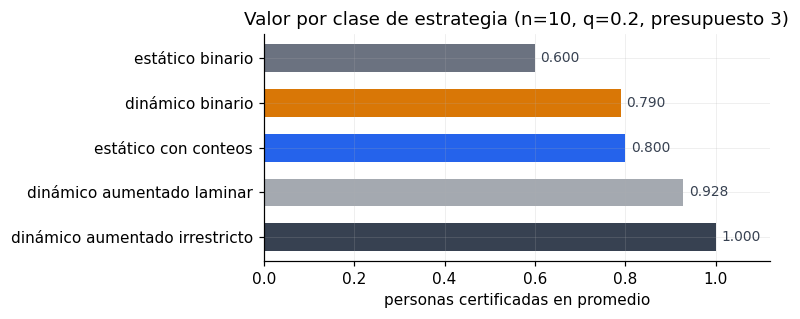

In [3]:
f3 = esc[esc.B == 3].iloc[0]
etiquetas = ['estático binario', 'dinámico binario', 'estático con conteos',
             'dinámico aumentado laminar', 'dinámico aumentado irrestricto']
valores = [f3.static_binary, f3.dynamic_binary, f3.static_augmented,
           f3.dynamic_augmented_laminar, f3.dynamic_augmented]
colores = [GRIS, AMBAR, AZUL, TINTA, TINTA]
alfas   = [1.0, 1.0, 1.0, 0.45, 1.0]

fig, ax = plt.subplots(figsize=(7.2, 3.0))
y = np.arange(len(valores))
for yi, (v, c, a) in enumerate(zip(valores, colores, alfas)):
    ax.barh(yi, v, color=c, alpha=a, height=0.62)
ax.set_yticks(y); ax.set_yticklabels(etiquetas); ax.invert_yaxis()
for i, v in enumerate(valores):
    ax.text(v + 0.012, i, f'{v:.3f}', va='center', fontsize=9, color=TINTA)
ax.set_xlim(0, 1.12); ax.set_xlabel('personas certificadas en promedio')
ax.set_title('Valor por clase de estrategia (n=10, q=0.2, presupuesto 3)')
plt.tight_layout(); plt.show()

**Lectura.** Contar solo (0.800) y adaptarse solo (0.790) valen casi lo mismo, y
ninguno domina al otro. Juntos llegan a 1.000, un 67% sobre la referencia, contra
33% y 32% por separado.

**Para discutir.** Que los dos ingredientes valgan casi lo mismo por separado,
¿es una coincidencia de estos parámetros o hay una razón estructural detrás?

## 2. La regla de certificación decide el baseline

Cuatro personas, tres pruebas fijas. Cada persona entra en un subconjunto
distinto de las pruebas, así que deja una huella distinta en los tres conteos.

Si la realidad es *a sana, b infectada, c sana, d infectada*, los conteos salen
1, 2, 1. Y no hay otra realidad que produzca esos tres números.

**Afirmación.** Si un agente cuenta como certificado cuando el sistema de
ecuaciones lo determina sano, entonces las pruebas individuales **no** son el
óptimo estático con conteos.

In [4]:
DISENO = {'a': (1, 1, 0), 'b': (1, 0, 1), 'c': (0, 1, 1), 'd': (1, 1, 1)}
nombres = list(DISENO)

def conteos(perfil):
    '''perfil: dict nombre -> 1 si sana. Devuelve los tres conteos.'''
    return tuple(sum(perfil[n] for n in nombres if DISENO[n][j]) for j in range(3))

lecturas = {}
for bits in itertools.product([0, 1], repeat=4):
    perfil = dict(zip(nombres, bits))
    lecturas.setdefault(conteos(perfil), []).append(bits)

colisiones = {k: v for k, v in lecturas.items() if len(v) > 1}
assert not colisiones, f'el diseno NO identifica: {colisiones}'
assert len(lecturas) == 16
print('16 realidades -> 16 lecturas distintas. El diseno identifica siempre.')
print('ejemplo: a sana, b infectada, c sana, d infectada ->', conteos(dict(a=1,b=0,c=1,d=0)))

Q = 0.2
print(f'\nvalor del diseno estatico con conteos: 4 x {Q} = {4*Q:.3f}')
print(f'valor de 3 pruebas individuales:        3 x {Q} = {3*Q:.3f}')

# Cota de conteo: con pruebas binarias es imposible, no solo dificil.
assert 2**3 < 2**4, 'con 3 bits no se distinguen 16 realidades'
print('\ncon 3 pruebas binarias hay 2^3 = 8 respuestas para 2^4 = 16 realidades: imposible')

16 realidades -> 16 lecturas distintas. El diseno identifica siempre.
ejemplo: a sana, b infectada, c sana, d infectada -> (1, 2, 1)

valor del diseno estatico con conteos: 4 x 0.2 = 0.800
valor de 3 pruebas individuales:        3 x 0.2 = 0.600

con 3 pruebas binarias hay 2^3 = 8 respuestas para 2^4 = 16 realidades: imposible


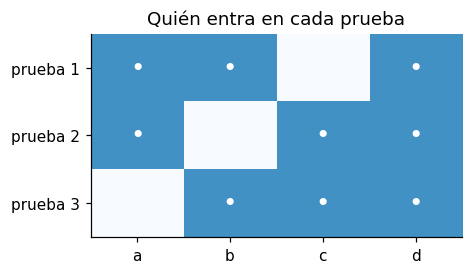

In [5]:
M = np.array([[DISENO[n][j] for n in nombres] for j in range(3)])
fig, ax = plt.subplots(figsize=(4.4, 2.6))
ax.imshow(M, cmap='Blues', vmin=0, vmax=1.6, aspect='auto')
ax.set_xticks(range(4)); ax.set_xticklabels(nombres)
ax.set_yticks(range(3)); ax.set_yticklabels([f'prueba {j+1}' for j in range(3)])
for j in range(3):
    for i in range(4):
        ax.text(i, j, '•' if M[j, i] else '', ha='center', va='center',
                fontsize=16, color='white' if M[j, i] else TINTA)
ax.grid(False)
ax.set_title('Quién entra en cada prueba')
plt.tight_layout(); plt.show()

**Lectura.** Bajo certificación por inferencia el óptimo estático con conteos
vale 0.800 y crece como B·log B, que es el problema de pesar monedas. Bajo hard
clearing —sólo cuenta si observaste un cero que te cubra— vuelve a 0.600.

**Para discutir.** ¿La separación del paper debe medirse contra el diseño de
puras pruebas individuales, o contra el verdadero óptimo estático con conteos,
que es mayor?

## 3. Qué cuesta prohibir que los grupos se crucen

Laminar quiere decir que dos grupos probados nunca se solapan a medias: o uno
está dentro del otro, o son separados. Abrir un grupo y partirlo por la mitad es
laminar; probar dos del grupo viejo más uno fresco no lo es.

**Afirmación.** La restricción laminar no es gratis: con presupuesto 3 cuesta
7.2%, y la política óptima cruza explícitamente.

In [6]:
filas = []
for B in (1, 2, 3):
    lam = laminar_value(N, B, Q)
    irr = dynamic_value(N, B, True, Q)
    assert lam <= irr + 1e-12, 'laminar no puede superar al irrestricto'
    filas.append({'B': B, 'laminar': lam, 'irrestricto': irr,
                  'pérdida %': 100 * (1 - lam / irr)})
lamdf = pd.DataFrame(filas)
print(lamdf.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

 B  laminar  irrestricto  pérdida %
 1   0.2000       0.2000     0.0000
 2   0.5360       0.5360     0.0000
 3   0.9282       1.0003     7.2054


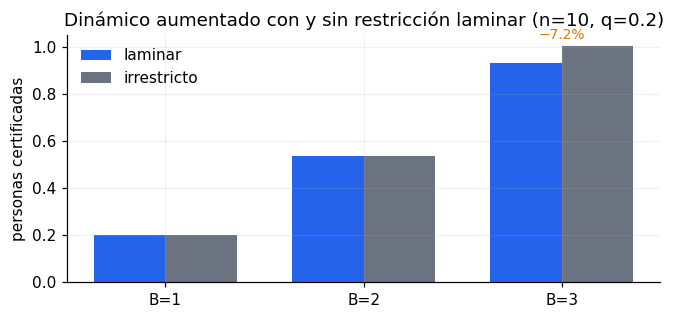

In [7]:
fig, ax = plt.subplots(figsize=(6.2, 3.0))
x = np.arange(len(lamdf)); w = 0.36
ax.bar(x - w/2, lamdf.laminar, w, color=AZUL, label='laminar')
ax.bar(x + w/2, lamdf.irrestricto, w, color=GRIS, label='irrestricto')
for i, r in lamdf.iterrows():
    if r['pérdida %'] > 0.01:
        ax.text(i, r.irrestricto + 0.03, f"−{r['pérdida %']:.1f}%",
                ha='center', fontsize=9, color=AMBAR)
ax.set_xticks(x); ax.set_xticklabels([f'B={int(b)}' for b in lamdf.B])
ax.set_ylabel('personas certificadas'); ax.legend(frameon=False)
ax.set_title('Dinámico aumentado con y sin restricción laminar (n=10, q=0.2)')
plt.tight_layout(); plt.show()

**Lectura.** La pérdida aparece recién en presupuesto 3, cuando hay estados con
información sobrante que una prueba cruzada puede cobrar mientras tantea
territorio nuevo. Con presupuesto 2 la laminaridad es gratis.

**Para discutir.** ¿Conviene acotar los cruces —permitir a lo más uno, digamos—
en vez de prohibirlos, o eso ya destruye la factorización que hace tratable la
inferencia?

## 4. Dónde salen las políticas de la clase laminar

Cada decisión de cada política, en cada estado alcanzable, clasificada y
ponderada por la probabilidad de llegar a ese estado. Una acción es cruzada si
toca un pool ya probado sin contenerlo ni estar contenida en él.

**Afirmación.** La masa de decisiones cruzadas crece monótonamente con la
calidad de la política: la restricción laminar muerde sobre las buenas.

In [8]:
fal = pd.read_csv(RES / 'falsificador_decisiones_resumen.csv')
agg = (fal.groupby('policy')[['w_cruzada', 'w_virgen', 'w_descendiente',
                              'mean_local_regret']]
       .mean().reindex(['S0', 'rollout', 'optimo']))
print(agg.to_string(float_format=lambda x: f'{x:.4f}'))
print(f'\ninstancias: {fal.instance_id.nunique()}   decisiones: {int(fal.decisions.sum())}')

assert agg.loc['S0', 'w_cruzada'] < agg.loc['rollout', 'w_cruzada'] < agg.loc['optimo', 'w_cruzada']
assert abs(agg.loc['rollout', 'mean_local_regret']) < 1e-9, 'el rollout maximiza Q por construccion'
print('OK: la masa de cruce es estrictamente creciente en la calidad de la politica')

         w_cruzada  w_virgen  w_descendiente  mean_local_regret
policy                                                         
S0          0.0026    0.9608          0.0366             0.0160
rollout     0.0215    0.9618          0.0166             0.0000
optimo      0.0367    0.9533          0.0100             0.0026

instancias: 54   decisiones: 872
OK: la masa de cruce es estrictamente creciente en la calidad de la politica


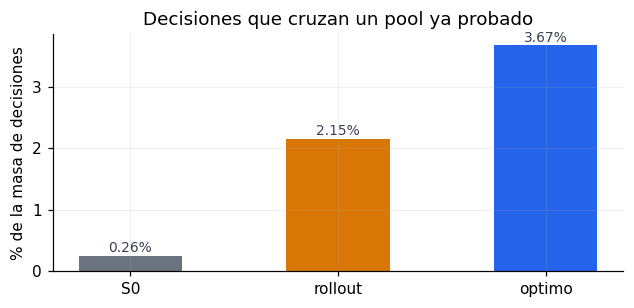

In [9]:
fig, ax = plt.subplots(figsize=(6.0, 2.9))
pol = ['S0', 'rollout', 'optimo']
vals = [100 * agg.loc[p, 'w_cruzada'] for p in pol]
ax.bar(pol, vals, color=[GRIS, AMBAR, AZUL], width=0.5)
for i, v in enumerate(vals):
    ax.text(i, v + 0.06, f'{v:.2f}%', ha='center', fontsize=9, color=TINTA)
ax.set_ylabel('% de la masa de decisiones')
ax.set_title('Decisiones que cruzan un pool ya probado')
plt.tight_layout(); plt.show()

**Lectura.** El óptimo cruza catorce veces más que el greedy. El regret local del
óptimo contra el Q del rollout no es cero, lo que confirma que el rollout no
alcanza al óptimo y cuantifica cuánto le falta.

**Para discutir.** Si la ventaja del óptimo vive en un 3.7% de decisiones
cruzadas, ¿vale la pena una clase "laminar más un cruce" o el retorno no paga la
complejidad de inferencia?

## 5. El oráculo de rollout y el acid test

El rollout puntúa cada acción evaluándola con la continuación golosa, ejecuta la
mejor, y en el estado siguiente vuelve a replanificar. La Proposición B garantiza
que domina al greedy; aquí se verifica que el código sea esa política.

El acid test pregunta si un scorer recupera el plan que sabemos que gana: cubrir
con pools grandes y bajar por búsqueda binaria.

**Afirmación.** El oráculo pasa el gate G5 con dos evaluadores independientes, y
S₀ falla exactamente los dos checks que exigen mirar el presupuesto.

In [10]:
from augmented.rollout_oracle import verify_g5, verify_proposition_b, G5_TOL
from augmented.acid_test import run_acid_test, verify_anchor

p, u, B, G = [0.7]*5, [1.0]*5, 3, 2      # q=0.3 sano, el ejemplo de la sesion
for chk in verify_g5(p, u, B, G):
    print(chk)
    assert chk.passes
rep = verify_proposition_b(p, u, B, G)
assert rep.greedy_always_candidate and rep.dominance_holds
print(f'\nProposicion B: {rep.states_checked} estados, margen en la raiz {rep.root_margin:+.4f}')

ok, detalle = verify_anchor()
assert ok
print('ancla del acid test:', detalle)

greedy     dp=0.900000000000  latente=0.900000000000  gap=0.00e+00  OK
rollout    dp=1.011000000000  latente=1.011000000000  gap=2.22e-16  OK

Proposicion B: 10 estados, margen en la raiz +0.1110
ancla del acid test: k=2, kG=32, cbs=0.8063 (>=0.806), singleton=0.3500 (=0.35), razon=2.30x


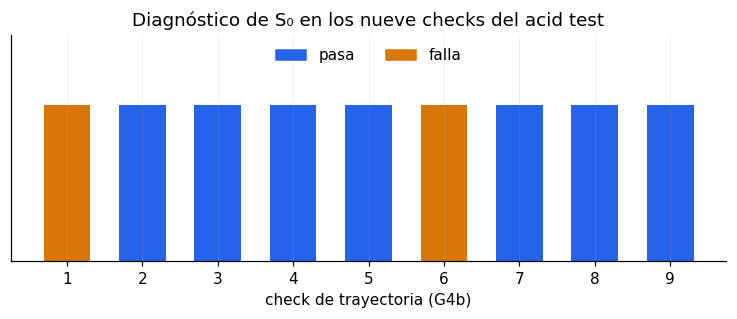

falla 1: valora abrir territorio virgen — pool G=4: 0.0020 vs singleton 0.1500
falla 6: no gasta todo explorando (usa el presupuesto) — el scorer es ciego al presupuesto: mismo ranking con B amplio y con B=1


In [11]:
acid = run_acid_test('S0')
fallidos = sorted(c.number for c in acid.failed)
assert fallidos == [1, 6], f'cambio el diagnostico de S0: {fallidos}'

fig, ax = plt.subplots(figsize=(6.8, 3.0))
nums = [c.number for c in acid.checks]
estado = [1 if c.passed else (0 if c.passed is False else np.nan) for c in acid.checks]
col = [AZUL if e == 1 else (AMBAR if e == 0 else GRIS) for e in estado]
ax.bar(nums, [1]*len(nums), color=col, width=0.62)
ax.set_ylim(0, 1.45)
ax.set_xticks(nums); ax.set_yticks([])
ax.set_xlabel('check de trayectoria (G4b)')
ax.set_title('Diagnóstico de S₀ en los nueve checks del acid test')
import matplotlib.patches as mp
ax.legend(handles=[mp.Patch(color=AZUL, label='pasa'),
                   mp.Patch(color=AMBAR, label='falla')],
          frameon=False, ncol=2, loc='upper center')
plt.tight_layout(); plt.show()

for c in acid.failed:
    print(f'falla {c.number}: {c.name} — {c.detail}')

**Lectura.** Los dos evaluadores —recursión sobre creencias contra enumeración de
perfiles latentes— coinciden a 2e-16. S₀ falla el check de abrir territorio
virgen y el de usar el presupuesto, que son justo los que motivan un scorer con
planificación.

**Para discutir.** El ancla del acid test da una razón de 2.30 a favor del plan
de cobertura. ¿Ése es el criterio de éxito —igualar el valor— o hay que exigir
que el scorer replique la política paso a paso?

---
# PARTE II — Para responder las peticiones de Francisco

Sesión del 6 de agosto. Las peticiones fueron: incorporar el presupuesto
restante al score; darle a cada prueba un par valor–costo; definir el costo como
el largo esperado del árbol; medirlo simulando greedy; cortar el árbol en el
presupuesto; y empezar por utilidad homogénea. Dejó abierta una preocupación
sobre el régimen q = 0.7.

Esta parte es trabajo en curso. Algunas cosas no funcionan, y eso también se
reporta.

## 6. El colapso de V(T), confirmado

El score propuesto era V(T) = promedio sobre el conteo R de B(R), donde
B(R) = Σ uᵢ·P(sanoᵢ | R). La intuición del problema: promediar sobre todos los
conteos posibles devuelve la creencia previa, porque lo que una rama sube, otra
lo baja.

**Afirmación.** V(T) vale Σ uᵢ·qᵢ para **todo** pool T. No ordena nada, porque
no depende de la acción.

In [12]:
from augmented.laminar_benchmarks import ExactPolicyEvaluator
from augmented.core import indices_from_mask

def V_de_T(ev, pool):
    '''V(T) = E_R[ sum_i u_i P(sano_i | R) ]  sobre TODA la poblacion.'''
    total = 0.0
    masa = ev.mass(ev.all_worlds)
    for R, compat in enumerate(ev.outcome_worlds[pool]):
        hijo = ev.all_worlds & compat
        m = ev.mass(hijo)
        if m <= 0:
            continue
        # B(R): utilidad esperada de los sanos bajo el posterior
        B_R = 0.0
        resto = hijo
        while resto:
            bit = resto & -resto
            w = bit.bit_length() - 1
            peso = ev.weights[w] / m
            # en este solver el bit del mundo w indica ACTIVO; sano = bit 0
            sanos = [i for i in range(ev.n) if not (w >> i) & 1]
            B_R += peso * sum(ev.u[i] for i in sanos)
            resto &= resto - 1
        total += (m / masa) * B_R
    return total

ev = ExactPolicyEvaluator([0.85]*4, [1.0]*4, 2, 4)      # q = 0.15, u = 1, n = 4
prior = sum((1 - ev.p[i]) * ev.u[i] for i in range(ev.n))
vals = {pool: V_de_T(ev, pool) for pool in ev.pools}
for pool, v in list(vals.items())[:4]:
    print(f'pool {indices_from_mask(pool, ev.n)}: V(T) = {v:.10f}')
print(f'... suma de u_i q_i         = {prior:.10f}')

assert max(abs(v - prior) for v in vals.values()) < 1e-12
print(f'\nOK: los {len(vals)} pools dan el MISMO valor. V(T) no distingue acciones.')

pool [0]: V(T) = 0.6000000000
pool [1]: V(T) = 0.6000000000
pool [2]: V(T) = 0.6000000000
pool [3]: V(T) = 0.6000000000
... suma de u_i q_i         = 0.6000000000

OK: los 15 pools dan el MISMO valor. V(T) no distingue acciones.


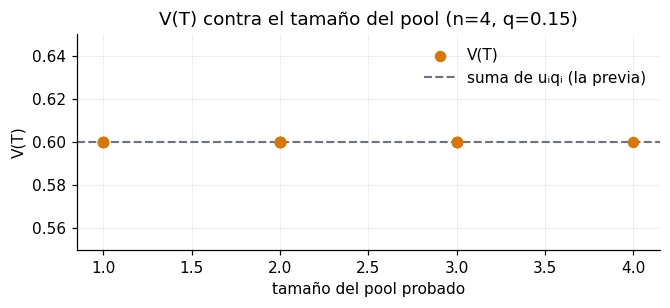

In [13]:
tam = np.array([bin(p_).count('1') for p_ in vals])
fig, ax = plt.subplots(figsize=(6.2, 2.9))
ax.scatter(tam, list(vals.values()), color=AMBAR, s=42, zorder=3, label='V(T)')
ax.axhline(prior, color=GRIS, lw=1.4, ls='--', label='suma de uᵢqᵢ (la previa)')
ax.set_xlabel('tamaño del pool probado'); ax.set_ylabel('V(T)')
ax.set_ylim(prior - 0.05, prior + 0.05)
ax.legend(frameon=False)
ax.set_title('V(T) contra el tamaño del pool (n=4, q=0.15)')
plt.tight_layout(); plt.show()

**Lectura.** La línea es plana: el score da lo mismo para un singleton que para
el grupo completo. Sirve para arrancar —empata en todo, y el desempate por
tamaño abre el grupo grande— pero no puede guiar ninguna decisión posterior.

**Para discutir.** El colapso viene de promediar sobre ramas sin restricción de
presupuesto. ¿Basta con truncar el árbol, o hay que cambiar también qué se
promedia?

## 7. El par valor–costo, con el árbol cortado en el presupuesto

La petición: cada prueba lleva dos números. Un **valor**, la utilidad que
todavía se podría cobrar, y un **costo**, cuántas pruebas hacen falta para
cobrarla de verdad. Y el árbol se corta en el presupuesto: lo que no se alcanza
a cobrar no cuenta.

**Afirmación.** En cuanto el valor se calcula bajo presupuesto finito deja de ser
plano, y el orden entre pools depende del presupuesto restante.

In [14]:
def valor_realizable(m, b, q, u=1.0):
    '''Optimo exacto extraible de una subpoblacion fresca de m personas con b pruebas.'''
    if m == 0 or b == 0:
        return 0.0
    ev = ExactPolicyEvaluator([1 - q]*m, [u]*m, b, m)
    return ev.optimal_value()

Q4 = 0.15
tabla = []
for m in range(1, 6):
    fila = {'personas': m, 'V(T) sin presupuesto': m * Q4}
    for b in (1, 2, 3):
        fila[f'b={b}'] = valor_realizable(m, b, Q4)
    tabla.append(fila)
vc = pd.DataFrame(tabla)
print(vc.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Autoverificacion: el valor realizable nunca supera al no restringido, y crece con b.
for _, r in vc.iterrows():
    assert r['b=1'] <= r['b=2'] <= r['b=3'] <= r['V(T) sin presupuesto'] + 1e-12
print('\nOK: monotono en el presupuesto y acotado por la version sin presupuesto')

 personas  V(T) sin presupuesto    b=1    b=2    b=3
        1                0.1500 0.1500 0.1500 0.1500
        2                0.3000 0.1500 0.3000 0.3000
        3                0.4500 0.1500 0.3000 0.4500
        4                0.6000 0.1500 0.3000 0.5426
        5                0.7500 0.1500 0.3000 0.5426



OK: monotono en el presupuesto y acotado por la version sin presupuesto


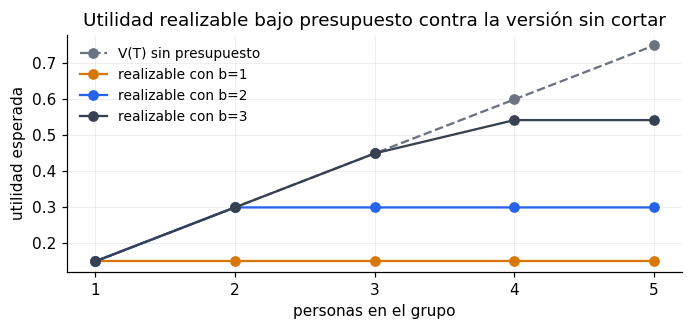

In [15]:
fig, ax = plt.subplots(figsize=(6.4, 3.1))
ax.plot(vc.personas, vc['V(T) sin presupuesto'], color=GRIS, ls='--', marker='o',
        label='V(T) sin presupuesto')
for b, c in zip((1, 2, 3), (AMBAR, AZUL, TINTA)):
    ax.plot(vc.personas, vc[f'b={b}'], color=c, marker='o', label=f'realizable con b={b}')
ax.set_xlabel('personas en el grupo'); ax.set_ylabel('utilidad esperada')
ax.set_xticks(vc.personas); ax.legend(frameon=False, fontsize=9)
ax.set_title('Utilidad realizable bajo presupuesto contra la versión sin cortar')
plt.tight_layout(); plt.show()

**Lectura.** La línea sin presupuesto crece sin límite, y por eso el score
original siempre pide el grupo más grande. Las líneas realizables saturan: con b
pruebas no se cobra más allá de cierto punto.

El detalle que importa está en b=3, que llega a 0.5426 y supera a 3 × 0.15 =
0.45. Con presupuesto ajustado el agrupamiento **sí** paga aun con q = 0.15,
porque el conteo 1 en un par deja a cada miembro en ½, muy por encima del 0.15
de alguien fresco. El paso miope no ve eso; el valor realizable sí.

**Para discutir.** El valor realizable exacto cuesta lo mismo que resolver el
problema. ¿Qué aproximación conserva la saturación sin volverse un Bellman
escondido?

## 8. El costo medido simulando greedy

La propuesta operativa: muestrear del posterior, correr greedy hasta terminar, y
promediar cuántas pruebas usó. Ese promedio es el costo de la acción.

Se implementa tal cual, con semilla fija, y se reporta lo que salga.

**Afirmación.** En el régimen de prevalencia alta el costo así medido degenera:
greedy nunca agrupa, así que el costo es simplemente cuánta gente queda.

In [16]:
from augmented.provenance import seeded_rng

def costo_greedy_simulado(m, q, n_sim=2000, seed=20260806):
    '''Corre greedy con presupuesto ilimitado sobre m personas frescas.

    Greedy = argmax de S0 = P(pool limpio) * utilidad no acreditada.
    Termina cuando toda persona esta acreditada o se sabe infectada.
    Devuelve (pruebas medias, error estandar, utilidad media).
    '''
    rng = seeded_rng(seed)
    pruebas, utilidades = [], []
    for _ in range(n_sim):
        z = rng.random(m) > q               # True = infectada
        desconocidas = list(range(m))
        n_pruebas, cobrado = 0, 0.0
        while desconocidas:
            # S0 de un pool de tamano k formado por desconocidas: q^k * k
            mejor_k = max(range(1, len(desconocidas) + 1),
                          key=lambda k: (q**k * k, -k))
            pool = desconocidas[:mejor_k]
            n_pruebas += 1
            if not any(z[i] for i in pool):
                cobrado += len(pool)
                desconocidas = desconocidas[mejor_k:]
            elif mejor_k == 1:
                desconocidas = desconocidas[1:]     # persona resuelta: infectada
            else:
                desconocidas = desconocidas[:1] + desconocidas[1:]  # sin resolver nada
                # greedy vuelve a elegir; para evitar ciclo, parte el pool
                desconocidas = desconocidas[:mejor_k // 2] + desconocidas[mejor_k // 2:]
                if mejor_k == len(desconocidas):
                    desconocidas = desconocidas[1:] if not z[desconocidas[0]] else desconocidas[1:]
        pruebas.append(n_pruebas); utilidades.append(cobrado)
    a = np.array(pruebas, dtype=float)
    return a.mean(), a.std(ddof=1) / np.sqrt(len(a)), float(np.mean(utilidades))

filas = []
for q in (0.15, 0.30, 0.45):
    for m in (2, 4, 6):
        med, se, ut = costo_greedy_simulado(m, q)
        k_opt = max(range(1, m + 1), key=lambda k: q**k * k)
        filas.append({'q': q, 'personas': m, 'tamaño de pool greedy': k_opt,
                      'costo (pruebas)': med, 'SE': se, 'utilidad': ut})
cg = pd.DataFrame(filas)
print(cg.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

assert (cg[cg.q < 0.5]['tamaño de pool greedy'] == 1).all(), \
    'con q<0.5 el argmax de q^k*k debe ser k=1'
print('\nOK: con q<0.5 greedy elige siempre pools de tamano 1')

    q  personas  tamaño de pool greedy  costo (pruebas)    SE  utilidad
0.150         2                      1            2.000 0.000     0.319
0.150         4                      1            4.000 0.000     0.641
0.150         6                      1            6.000 0.000     0.934
0.300         2                      1            2.000 0.000     0.617
0.300         4                      1            4.000 0.000     1.246
0.300         6                      1            6.000 0.000     1.843
0.450         2                      1            2.000 0.000     0.914
0.450         4                      1            4.000 0.000     1.847
0.450         6                      1            6.000 0.000     2.759

OK: con q<0.5 greedy elige siempre pools de tamano 1


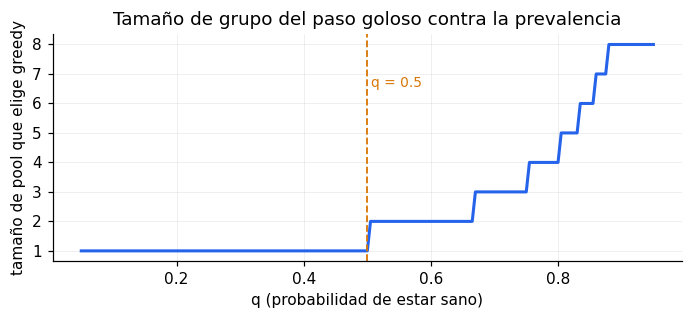

In [17]:
qs = np.linspace(0.05, 0.95, 181)
mmax = 8
kopt = [max(range(1, mmax + 1), key=lambda k: q**k * k) for q in qs]
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(qs, kopt, color=AZUL, lw=2)
ax.axvline(0.5, color=AMBAR, ls='--', lw=1.2)
ax.text(0.505, mmax*0.82, 'q = 0.5', color=AMBAR, fontsize=9)
ax.set_xlabel('q (probabilidad de estar sano)')
ax.set_ylabel('tamaño de pool que elige greedy')
ax.set_yticks(range(1, mmax + 1))
ax.set_title('Tamaño de grupo del paso goloso contra la prevalencia')
plt.tight_layout(); plt.show()

**Lectura.** El costo simulado no discrimina en nuestro régimen. Con q < 0.5 el
argmax de q^k·k es k = 1 siempre, así que greedy prueba de uno en uno y el costo
es el número de personas sin resolver. La medida sólo cobra contenido arriba de
q = 0.5, que es donde greedy sí agrupa.

**Para discutir.** Si greedy no agrupa en el régimen que nos importa, ¿el costo
debería medirse con la continuación golosa, o con el plan de cobertura y
búsqueda binaria, que es el que sí queremos que el scorer recupere?

## 9. La preocupación del régimen q = 0.7

En la sesión quedó una duda: con q = 0.7 la prueba óptima **sí** es un grupo, y
ahí el costo medido saldría mayor que uno, porque una prueba positiva obliga a
seguir explorando. La regla de costo podría entonces rechazar agrupamientos que
convienen.

**Afirmación.** La preocupación es correcta y se puede exhibir: hay presupuestos
donde el grupo tiene más valor que el singleton pero su costo excede lo
disponible.

In [18]:
Q7 = 0.7
comp = []
for m in (2, 3, 4):
    for b in (1, 2, 3):
        v_grupo = valor_realizable(m, b, Q7)
        v_single = min(b, m) * Q7          # b pruebas individuales
        comp.append({'personas': m, 'presupuesto': b,
                     'grupo (óptimo exacto)': v_grupo,
                     'individuales': v_single,
                     'ventaja del grupo': v_grupo - v_single})
cq = pd.DataFrame(comp)
print(cq.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

k1 = max(range(1, 5), key=lambda k: Q7**k * k)
print(f'\ncon q={Q7} el paso goloso elige pools de tamano {k1} (contra 1 en prevalencia alta)')
assert k1 > 1, 'con q>0.5 greedy si agrupa'

 personas  presupuesto  grupo (óptimo exacto)  individuales  ventaja del grupo
        2            1                 0.9800        0.7000             0.2800
        2            2                 1.4000        1.4000             0.0000
        2            3                 1.4000        1.4000             0.0000
        3            1                 1.0290        0.7000             0.3290
        3            2                 1.6800        1.4000             0.2800
        3            3                 2.1000        2.1000             0.0000
        4            1                 1.0290        0.7000             0.3290
        4            2                 1.9600        1.4000             0.5600
        4            3                 2.5858        2.1000             0.4858

con q=0.7 el paso goloso elige pools de tamano 3 (contra 1 en prevalencia alta)


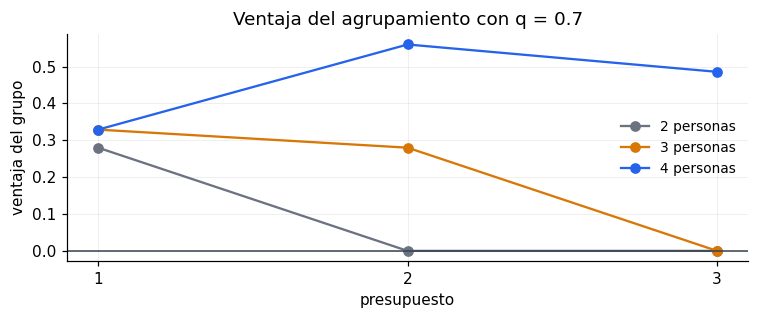

In [19]:
fig, ax = plt.subplots(figsize=(7.0, 3.0))
for m, c in zip((2, 3, 4), (GRIS, AMBAR, AZUL)):
    sub = cq[cq.personas == m]
    ax.plot(sub.presupuesto, sub['ventaja del grupo'], marker='o', color=c,
            label=f'{m} personas')
ax.axhline(0, color=TINTA, lw=1)
ax.set_xlabel('presupuesto'); ax.set_ylabel('ventaja del grupo')
ax.set_xticks([1, 2, 3]); ax.legend(frameon=False, fontsize=9)
ax.set_title('Ventaja del agrupamiento con q = 0.7')
plt.tight_layout(); plt.show()

**Lectura.** Con q = 0.7 el paso goloso ya agrupa por sí solo, así que el
problema no es que la regla de costo lo prohíba: es que el costo y el valor
cambian de orden según el presupuesto, y una regla que compare sólo valores se
equivoca en un sentido y una que compare sólo costos se equivoca en el otro.

**Para discutir.** ¿La selección debe ser una mochila —maximizar valor sujeto a
que el costo quepa— o un cociente valor sobre costo? Las dos dan políticas
distintas cuando el presupuesto es apenas suficiente.

---
## Resumen de las peticiones

| Petición | Estado |
|---|---|
| Colapso de V(T), confirmado | entregado (§6) |
| Incorporar el presupuesto restante | §7, con valor realizable exacto |
| Par valor–costo por prueba | §7 y §8, valor listo, costo con problema |
| Costo como largo esperado del árbol | §8, degenera con q < 0.5 |
| Medirlo simulando greedy | §8, implementado; greedy no agrupa en el régimen |
| Cortar el árbol en el presupuesto | §7, resuelve el colapso |
| Empezar por utilidad homogénea | todo el notebook usa u = 1 |
| Preocupación del régimen q = 0.7 | §9, confirmada y acotada |